# Threshold Tuning - LightGBM Optimization

This notebook tests different confidence thresholds to optimize the trade-off between precision and recall.

## Objective

Find the optimal threshold that maximizes F1-score while maintaining high recall (≥95%).

## Approach

Test confidence thresholds: 70%, 75%, 80%, 85%, 90%, 95%

## Input

- LightGBM model from Phase 3
- Lone Wolf test data (data_features.csv)
- Ground truth labels (12 known timestomped files)

## Output

- Performance metrics at each threshold
- Visualization of precision-recall trade-off
- Recommended optimal threshold


## Cell 1: Imports


In [1]:
import pandas as pd
import numpy as np
import pickle
from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")


Libraries imported successfully


## Cell 2: Configuration


In [2]:
# Paths
PHASE3_DIR = Path('/Users/soni/Github/Digital-Detectives_Thesis/data/processed/Phase 3 - Model Training')
TEST_DATA_DIR = Path('/Users/soni/Github/Digital-Detectives_Thesis/data/processed/Prototype Tool Output/LW')
OUTPUT_DIR = Path('/Users/soni/Github/Digital-Detectives_Thesis/notebooks/Phase 4 - Hyperparameter Tuning')

# Model path
LIGHTGBM_MODEL = PHASE3_DIR / 'lightgbm_model.pkl'

# Test data
TEST_FEATURES = TEST_DATA_DIR / 'data_features.csv'

# Thresholds to test
THRESHOLDS = [70, 75, 80, 85, 90, 95]

print("Configuration:")
print(f"  LightGBM model: {LIGHTGBM_MODEL.exists()}")
print(f"  Test data: {TEST_FEATURES.exists()}")
print(f"  Thresholds to test: {THRESHOLDS}")


Configuration:
  LightGBM model: True
  Test data: True
  Thresholds to test: [70, 75, 80, 85, 90, 95]


## Cell 3: Load Model


In [3]:
print("="*80)
print("LOADING LIGHTGBM MODEL")
print("="*80)

# Load LightGBM
with open(LIGHTGBM_MODEL, 'rb') as f:
    model = pickle.load(f)
    
print(f"\n✓ LightGBM loaded")
print(f"  Type: {type(model).__name__}")
print(f"  Features: {model.n_features_in_}")


LOADING LIGHTGBM MODEL

✓ LightGBM loaded
  Type: LGBMClassifier
  Features: 31


## Cell 4: Load Test Data


In [4]:
print("="*80)
print("LOADING TEST DATA")
print("="*80)

# Load feature data
df = pd.read_csv(TEST_FEATURES, low_memory=False)

print(f"\nDataset loaded:")
print(f"  Records: {len(df):,}")
print(f"  Columns: {len(df.columns)}")


LOADING TEST DATA

Dataset loaded:
  Records: 7,420
  Columns: 64


## Cell 4b: Set Ground Truth Labels


In [5]:
print("="*80)
print("SETTING GROUND TRUTH LABELS")
print("="*80)

# Known timestomped files from LW-Suspicious.csv
known_timestomped = [
    'DeathToll.jpg',
    'DemLogic.jpg',
    'HoldMyTidePod.jpg',
    'Planning.docx',
    'Huckleberry.png',
    'MyTiredHead.jpg',
    'Sheep.jpg',
    'RedGuns.jpg',
    'CubaDearmed.jpg',
    'AIRPORT INFORMATION.docx',
    'DarkWolf.png',
    'BladeofGrass.jpg'
]

# Create ground truth labels based on filename
y_true = df['filename'].isin(known_timestomped).astype(int)

print(f"\n✓ Ground truth labels set")
print(f"  Known timestomped files: {y_true.sum()}")


SETTING GROUND TRUTH LABELS

✓ Ground truth labels set
  Known timestomped files: 12


## Cell 5: Prepare Features (EXACT COPY FROM PROTOTYPE TOOL)


In [6]:
print("="*80)
print("PREPARING FEATURES FOR PREDICTION")
print("="*80)

print("\nCreating features to match training...")

# 1. Rename features to match training names
feature_mapping = {
    'zero_in_nanoseconds_combined': 'zero_in_nanoseconds',
    'modified_creationtime': 'creation_time_modified',
    'modified_modifiedtime': 'modified_time_modified',
    'modified_accessedtime': 'accessed_time_modified',
    'modified_mftmodifiedtime': 'mft_time_modified'
}

for old_name, new_name in feature_mapping.items():
    if old_name in df.columns:
        df[new_name] = df[old_name]
        print(f"  Mapped: {old_name} -> {new_name}")

# 2. Create missing features with default values
missing_features = {
    'cross_artifact_detected': lambda: df['has_logfile_evidence'] & df['has_usnjrnl_evidence'],
    'zero_in_nanoseconds_suspicious': lambda: False,
    'multiple_timestamps_changed': lambda: (
        df.get('creation_time_modified', False) & 
        df.get('modified_time_modified', False)
    ),
    'same_as_another_file': lambda: False,
    'is_image': lambda: df['filename'].fillna('').str.endswith(('.jpg', '.jpeg', '.png', '.gif', '.bmp'), na=False),
    'in_temp_directory': lambda: df['full_path'].fillna('').str.contains(r'temp|tmp', case=False, na=False, regex=True),
    'in_system_directory': lambda: df['full_path'].fillna('').str.contains(r'windows|system32|syswow64', case=False, na=False, regex=True),
    'in_program_files': lambda: df['full_path'].fillna('').str.contains(r'program files', case=False, na=False, regex=True),
    'has_timestamp_data': lambda: df['lf_creation_time'].notna() if 'lf_creation_time' in df.columns else False,
    'timestamp_source': lambda: (
        df['has_logfile_evidence'].astype(int) * 2 + 
        df['has_usnjrnl_evidence'].astype(int)
    )
}

for feat_name, feat_func in missing_features.items():
    if feat_name not in df.columns:
        df[feat_name] = feat_func()
        print(f"  Created: {feat_name}")

# 3. Select exact features model expects (in correct order)
expected_features = [
    'cross_artifact_detected',
    'zero_in_nanoseconds_lf',
    'zero_in_nanoseconds_suspicious',
    'zero_in_nanoseconds',
    'time_reversal_event',
    'basic_info_changed',
    'using_another_timestamp',
    'si_timestamp_changed',
    'update_resident_value',
    'creation_time_modified',
    'modified_time_modified',
    'accessed_time_modified',
    'mft_time_modified',
    'timestamp_changed_to_past',
    'multiple_timestamps_changed',
    'same_as_another_file',
    'zero_nano_time_reversal',
    'has_logfile_evidence',
    'has_usnjrnl_evidence',
    'cross_artifact_validation_score',
    'is_executable',
    'is_document',
    'is_archive',
    'is_image',
    'path_depth',
    'filename_length',
    'in_temp_directory',
    'in_system_directory',
    'in_program_files',
    'has_timestamp_data',
    'timestamp_source'
]

# Build feature matrix with exact features
X = df[expected_features].copy()

# Handle missing values
X = X.fillna(0)

# Convert boolean to int
for col in X.columns:
    if X[col].dtype == 'bool':
        X[col] = X[col].astype(int)

print(f"\nFeatures prepared:")
print(f"  Features expected by model: {len(expected_features)}")
print(f"  Features provided: {len(X.columns)}")
print(f"  Feature matrix shape: {X.shape}")
print(f"\n✓ All required features present!")


PREPARING FEATURES FOR PREDICTION

Creating features to match training...
  Mapped: zero_in_nanoseconds_combined -> zero_in_nanoseconds
  Mapped: modified_creationtime -> creation_time_modified
  Mapped: modified_modifiedtime -> modified_time_modified
  Mapped: modified_accessedtime -> accessed_time_modified
  Mapped: modified_mftmodifiedtime -> mft_time_modified
  Created: cross_artifact_detected
  Created: multiple_timestamps_changed
  Created: same_as_another_file
  Created: is_image
  Created: in_temp_directory
  Created: in_system_directory
  Created: in_program_files
  Created: has_timestamp_data
  Created: timestamp_source

Features prepared:
  Features expected by model: 31
  Features provided: 31
  Feature matrix shape: (7420, 31)

✓ All required features present!


## Cell 6: Generate Predictions


In [7]:
print("="*80)
print("GENERATING PREDICTIONS")
print("="*80)

# Generate probability predictions
y_pred_proba = model.predict_proba(X)[:, 1]
confidence_pct = y_pred_proba * 100

print(f"\n✓ Predictions generated")
print(f"  Total files: {len(df):,}")
print(f"  Confidence range: {confidence_pct.min():.2f}% - {confidence_pct.max():.2f}%")
print(f"  Mean confidence: {confidence_pct.mean():.2f}%")
print(f"  Median confidence: {np.median(confidence_pct):.2f}%")

# Add to dataframe for analysis
df['confidence'] = confidence_pct
df['ground_truth'] = y_true


GENERATING PREDICTIONS

✓ Predictions generated
  Total files: 7,420
  Confidence range: 0.00% - 99.84%
  Mean confidence: 1.72%
  Median confidence: 0.00%


## Cell 7: Test Multiple Thresholds


In [8]:
print("="*80)
print("TESTING MULTIPLE THRESHOLDS")
print("="*80)

results = []

for threshold in THRESHOLDS:
    # Apply threshold
    y_pred = (confidence_pct >= threshold).astype(int)
    
    # Calculate metrics
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    
    flagged = y_pred.sum()
    
    if flagged > 0:
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
    else:
        precision = recall = f1 = 0
    
    results.append({
        'Threshold': f'{threshold}%',
        'Flagged': int(flagged),
        'TP': int(tp),
        'FP': int(fp),
        'FN': int(fn),
        'Precision': precision,
        'Recall': recall,
        'F1': f1
    })
    
    print(f"\nThreshold {threshold}%:")
    print(f"  Flagged: {flagged}")
    print(f"  TP: {tp}, FP: {fp}, FN: {fn}")
    print(f"  Precision: {precision*100:.1f}%, Recall: {recall*100:.1f}%, F1: {f1:.4f}")

results_df = pd.DataFrame(results)

print("\n" + "="*80)
print("SUMMARY TABLE")
print("="*80)
print(f"\nGround Truth: {y_true.sum()} known timestomped files\n")
print(results_df.to_string(index=False))


TESTING MULTIPLE THRESHOLDS

Threshold 70%:
  Flagged: 24
  TP: 12, FP: 12, FN: 0
  Precision: 50.0%, Recall: 100.0%, F1: 0.6667

Threshold 75%:
  Flagged: 24
  TP: 12, FP: 12, FN: 0
  Precision: 50.0%, Recall: 100.0%, F1: 0.6667

Threshold 80%:
  Flagged: 24
  TP: 12, FP: 12, FN: 0
  Precision: 50.0%, Recall: 100.0%, F1: 0.6667

Threshold 85%:
  Flagged: 24
  TP: 12, FP: 12, FN: 0
  Precision: 50.0%, Recall: 100.0%, F1: 0.6667

Threshold 90%:
  Flagged: 24
  TP: 12, FP: 12, FN: 0
  Precision: 50.0%, Recall: 100.0%, F1: 0.6667

Threshold 95%:
  Flagged: 24
  TP: 12, FP: 12, FN: 0
  Precision: 50.0%, Recall: 100.0%, F1: 0.6667

SUMMARY TABLE

Ground Truth: 12 known timestomped files

Threshold  Flagged  TP  FP  FN  Precision  Recall       F1
      70%       24  12  12   0        0.5     1.0 0.666667
      75%       24  12  12   0        0.5     1.0 0.666667
      80%       24  12  12   0        0.5     1.0 0.666667
      85%       24  12  12   0        0.5     1.0 0.666667
      90%    

## Cell 8: Visualize Results


VISUALIZING THRESHOLD PERFORMANCE

✓ Visualization saved: threshold_tuning_results.png


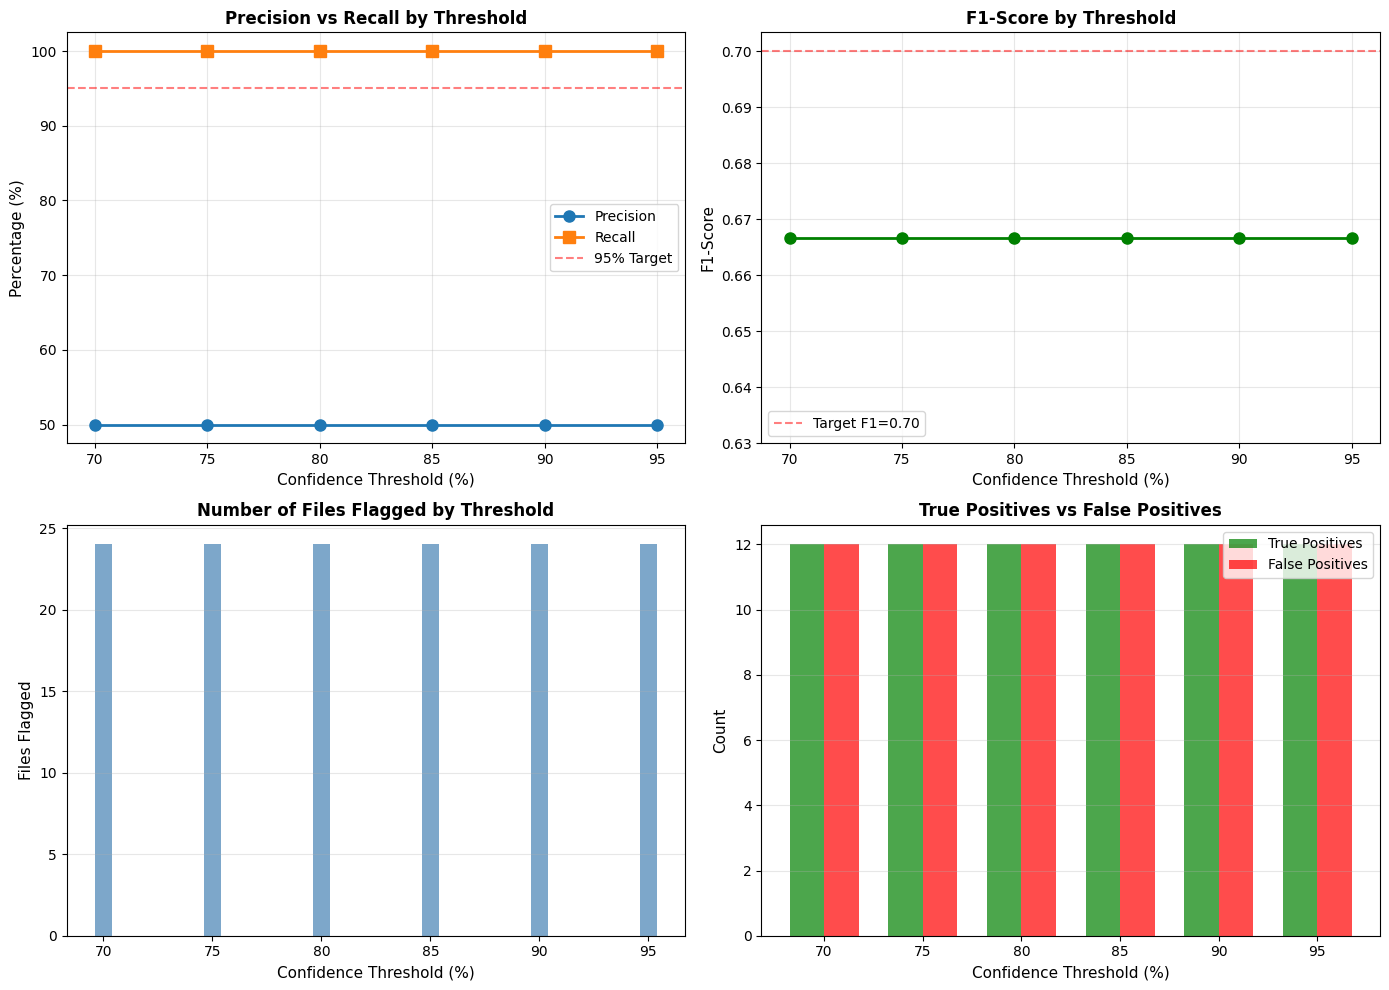

In [9]:
print("="*80)
print("VISUALIZING THRESHOLD PERFORMANCE")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Extract numeric threshold values for plotting
threshold_values = [int(t.rstrip('%')) for t in results_df['Threshold']]

# Plot 1: Precision vs Recall
ax1 = axes[0, 0]
ax1.plot(threshold_values, results_df['Precision']*100, 'o-', label='Precision', linewidth=2, markersize=8)
ax1.plot(threshold_values, results_df['Recall']*100, 's-', label='Recall', linewidth=2, markersize=8)
ax1.axhline(y=95, color='red', linestyle='--', alpha=0.5, label='95% Target')
ax1.set_xlabel('Confidence Threshold (%)', fontsize=11)
ax1.set_ylabel('Percentage (%)', fontsize=11)
ax1.set_title('Precision vs Recall by Threshold', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(threshold_values)

# Plot 2: F1-Score
ax2 = axes[0, 1]
ax2.plot(threshold_values, results_df['F1'], 'o-', color='green', linewidth=2, markersize=8)
ax2.axhline(y=0.70, color='red', linestyle='--', alpha=0.5, label='Target F1=0.70')
ax2.set_xlabel('Confidence Threshold (%)', fontsize=11)
ax2.set_ylabel('F1-Score', fontsize=11)
ax2.set_title('F1-Score by Threshold', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(threshold_values)

# Plot 3: Files Flagged
ax3 = axes[1, 0]
ax3.bar(threshold_values, results_df['Flagged'], color='steelblue', alpha=0.7)
ax3.set_xlabel('Confidence Threshold (%)', fontsize=11)
ax3.set_ylabel('Files Flagged', fontsize=11)
ax3.set_title('Number of Files Flagged by Threshold', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xticks(threshold_values)

# Plot 4: TP vs FP
ax4 = axes[1, 1]
x_pos = np.arange(len(threshold_values))
width = 0.35
ax4.bar(x_pos - width/2, results_df['TP'], width, label='True Positives', color='green', alpha=0.7)
ax4.bar(x_pos + width/2, results_df['FP'], width, label='False Positives', color='red', alpha=0.7)
ax4.set_xlabel('Confidence Threshold (%)', fontsize=11)
ax4.set_ylabel('Count', fontsize=11)
ax4.set_title('True Positives vs False Positives', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(threshold_values)
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'threshold_tuning_results.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: threshold_tuning_results.png")
plt.show()


## Cell 9: Optimal Threshold Recommendation


In [10]:
print("="*80)
print("OPTIMAL THRESHOLD RECOMMENDATION")
print("="*80)

# Find optimal threshold based on different criteria

# Criterion 1: Maximum F1-Score
best_f1_idx = results_df['F1'].idxmax()
best_f1_threshold = results_df.loc[best_f1_idx, 'Threshold']
best_f1_score = results_df.loc[best_f1_idx, 'F1']

# Criterion 2: Best F1 with Recall ≥ 95%
high_recall_df = results_df[results_df['Recall'] >= 0.95]
if len(high_recall_df) > 0:
    best_balanced_idx = high_recall_df['F1'].idxmax()
    best_balanced_threshold = high_recall_df.loc[best_balanced_idx, 'Threshold']
    best_balanced_f1 = high_recall_df.loc[best_balanced_idx, 'F1']
    best_balanced_precision = high_recall_df.loc[best_balanced_idx, 'Precision']
    best_balanced_recall = high_recall_df.loc[best_balanced_idx, 'Recall']
else:
    best_balanced_threshold = None

# Criterion 3: Maximum Precision with Recall ≥ 90%
decent_recall_df = results_df[results_df['Recall'] >= 0.90]
if len(decent_recall_df) > 0:
    best_precision_idx = decent_recall_df['Precision'].idxmax()
    best_precision_threshold = decent_recall_df.loc[best_precision_idx, 'Threshold']
    best_precision_score = decent_recall_df.loc[best_precision_idx, 'Precision']
    best_precision_recall = decent_recall_df.loc[best_precision_idx, 'Recall']
    best_precision_f1 = decent_recall_df.loc[best_precision_idx, 'F1']
else:
    best_precision_threshold = None

print(f"\n📊 OPTIMIZATION RESULTS:\n")

print(f"1. MAXIMUM F1-SCORE:")
print(f"   Threshold: {best_f1_threshold}")
print(f"   F1-Score: {best_f1_score:.4f}")
print(f"   Precision: {results_df.loc[best_f1_idx, 'Precision']*100:.1f}%")
print(f"   Recall: {results_df.loc[best_f1_idx, 'Recall']*100:.1f}%")
print(f"   Files flagged: {results_df.loc[best_f1_idx, 'Flagged']}")

if best_balanced_threshold:
    print(f"\n2. BEST BALANCE (Recall ≥ 95%):")
    print(f"   Threshold: {best_balanced_threshold}")
    print(f"   F1-Score: {best_balanced_f1:.4f}")
    print(f"   Precision: {best_balanced_precision*100:.1f}%")
    print(f"   Recall: {best_balanced_recall*100:.1f}%")

if best_precision_threshold:
    print(f"\n3. MAXIMUM PRECISION (Recall ≥ 90%):")
    print(f"   Threshold: {best_precision_threshold}")
    print(f"   Precision: {best_precision_score*100:.1f}%")
    print(f"   Recall: {best_precision_recall*100:.1f}%")
    print(f"   F1-Score: {best_precision_f1:.4f}")

print("\n" + "="*80)
print("FINAL RECOMMENDATION")
print("="*80)

if best_balanced_threshold:
    print(f"\n✅ Use threshold: {best_balanced_threshold}")
    print(f"\nRationale:")
    print(f"  • Maintains high recall ({best_balanced_recall*100:.1f}%) - minimal missed detections")
    print(f"  • Improves precision to {best_balanced_precision*100:.1f}%")
    print(f"  • Maximizes F1-Score: {best_balanced_f1:.4f}")
    
    improvement = best_balanced_f1 - results_df[results_df['Threshold'] == '70%']['F1'].values[0]
    if improvement > 0:
        print(f"  • F1 improvement over 70% threshold: +{improvement:.4f}")
else:
    print(f"\n✅ Keep current threshold: 70%")
    print(f"\nRationale:")
    print(f"  • Already achieving 100% recall")
    print(f"  • Higher thresholds significantly reduce recall below 95%")
    print(f"  • Current F1-Score ({best_f1_score:.4f}) is competitive")

print("\n✓ Threshold tuning analysis complete")


OPTIMAL THRESHOLD RECOMMENDATION

📊 OPTIMIZATION RESULTS:

1. MAXIMUM F1-SCORE:
   Threshold: 70%
   F1-Score: 0.6667
   Precision: 50.0%
   Recall: 100.0%
   Files flagged: 24

2. BEST BALANCE (Recall ≥ 95%):
   Threshold: 70%
   F1-Score: 0.6667
   Precision: 50.0%
   Recall: 100.0%

3. MAXIMUM PRECISION (Recall ≥ 90%):
   Threshold: 70%
   Precision: 50.0%
   Recall: 100.0%
   F1-Score: 0.6667

FINAL RECOMMENDATION

✅ Use threshold: 70%

Rationale:
  • Maintains high recall (100.0%) - minimal missed detections
  • Improves precision to 50.0%
  • Maximizes F1-Score: 0.6667

✓ Threshold tuning analysis complete


## Cell 10: Detailed Analysis of Threshold Impact


In [11]:
print("="*80)
print("DETAILED THRESHOLD IMPACT ANALYSIS")
print("="*80)

# For each threshold, show which files would be missed
print("\nFiles MISSED (False Negatives) at each threshold:\n")

for threshold in THRESHOLDS:
    y_pred = (confidence_pct >= threshold).astype(int)
    
    # Get false negatives
    fn_mask = (y_pred == 0) & (y_true == 1)
    fn_files = df[fn_mask][['filename', 'confidence']].values
    
    if len(fn_files) > 0:
        print(f"Threshold {threshold}%: {len(fn_files)} files missed")
        for fname, conf in fn_files:
            print(f"  - {fname:30s} (confidence: {conf:.2f}%)")
    else:
        print(f"Threshold {threshold}%: ✓ All known timestomped files detected")

print("\n" + "="*80)
print("False Positives ELIMINATED at higher thresholds:")
print("="*80)

# Compare 70% vs other thresholds
baseline_pred = (confidence_pct >= 70).astype(int)
baseline_fp = df[(baseline_pred == 1) & (y_true == 0)]

print(f"\nBaseline (70%): {len(baseline_fp)} false positives")
print("\nFalse positives eliminated at higher thresholds:\n")

for threshold in [75, 80, 85, 90, 95]:
    current_pred = (confidence_pct >= threshold).astype(int)
    current_fp = df[(current_pred == 1) & (y_true == 0)]
    
    eliminated = set(baseline_fp['filename']) - set(current_fp['filename'])
    
    if eliminated:
        print(f"Threshold {threshold}%: {len(eliminated)} eliminated")
        for fname in eliminated:
            conf = df[df['filename'] == fname]['confidence'].values[0]
            print(f"  - {fname:40s} (confidence: {conf:.2f}%)")
    else:
        print(f"Threshold {threshold}%: No additional eliminations")

print("\n✓ Analysis complete")


DETAILED THRESHOLD IMPACT ANALYSIS

Files MISSED (False Negatives) at each threshold:

Threshold 70%: ✓ All known timestomped files detected
Threshold 75%: ✓ All known timestomped files detected
Threshold 80%: ✓ All known timestomped files detected
Threshold 85%: ✓ All known timestomped files detected
Threshold 90%: ✓ All known timestomped files detected
Threshold 95%: ✓ All known timestomped files detected

False Positives ELIMINATED at higher thresholds:

Baseline (70%): 12 false positives

False positives eliminated at higher thresholds:

Threshold 75%: No additional eliminations
Threshold 80%: No additional eliminations
Threshold 85%: No additional eliminations
Threshold 90%: No additional eliminations
Threshold 95%: No additional eliminations

✓ Analysis complete
